# 5장 2강: 부스팅 계열 모델의 원리와 발전

## 실습 목표

이번 실습에서는 **Ames Housing** 데이터를 이용하여 부스팅 계열 모델의 순차 학습 원리와 주요 모델의 차이를 확인합니다.

- AdaBoost와 Gradient Boosting의 순차 학습 원리를 이해합니다.
- Gradient Boosting이 이전 모델의 잔차를 보완하는 흐름을 확인합니다.
- XGBoost와 LightGBM을 같은 데이터에서 비교합니다.
- `learning_rate`, `n_estimators`, `max_depth`의 역할을 확인합니다.
- Early Stopping의 목적을 이해합니다.
- 부스팅이 단계적으로 편향을 줄여가는 이유를 설명합니다.

> 이 실습에서는 5장 2강 교안에서 다룬 내용만 사용합니다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- scikit-learn
- xgboost
- lightgbm
- 데이터: `Ames_Housing.csv`

### 분석 목표

주택의 특성을 이용하여 `SalePrice`를 예측하는 회귀 문제입니다.

### 사용할 특성

- `OverallQual`
- `GrLivArea`
- `GarageCars`
- `GarageArea`
- `TotalBsmtSF`
- `1stFlrSF`
- `2ndFlrSF`
- `FullBath`
- `TotRmsAbvGrd`
- `YearBuilt`
- `YearRemodAdd`
- `Fireplaces`

예측 대상은 `SalePrice`입니다.

## 실습 준비

1. Ames Housing 데이터를 불러옵니다.
2. 사용할 숫자형 특성과 `SalePrice`를 선택합니다.
3. Train / Test 데이터로 분리합니다.
4. 같은 데이터에서 Gradient Boosting, XGBoost, LightGBM을 비교합니다.

In [1]:
import time

import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

house = pd.read_csv("Ames_Housing.csv")

features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
    "YearRemodAdd",
    "Fireplaces"
]

X = house[features]
y = house["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train 크기:", X_train.shape)
print("Test 크기:", X_test.shape)

print("\n[결측치]")
display(X.isna().sum().to_frame("missing"))

Train 크기: (1168, 12)
Test 크기: (292, 12)

[결측치]


,missing
OverallQual,0
GrLivArea,0
GarageCars,0
GarageArea,0
TotalBsmtSF,0
1stFlrSF,0
2ndFlrSF,0
FullBath,0
TotRmsAbvGrd,0
YearBuilt,0


---

# 필수 1. 부스팅의 순차 학습 원리 확인

## 문제 1. AdaBoost와 Gradient Boosting의 차이를 정리하세요.

### 요구사항

다음 두 모델이 이전 모델의 실수를 어떻게 보완하는지 각각 작성합니다.

- AdaBoost
- Gradient Boosting

### 확인 포인트

- AdaBoost는 틀린 샘플에 더 큰 가중치를 주는가?
- Gradient Boosting은 이전 모델의 잔차를 다음 모델이 학습하는가?

### Q1. AdaBoost와 Gradient Boosting은 각각 무엇에 집중하여 다음 모델을 학습하나요?

**답변:**  
- AdaBoost :    
    - 이전 모델이 틀린 샘플의 가중치를 높여 다음 모델이 그 샘플에 더 집중하게 학습하는 방법

- Gradiant Boosting : 
    - 이전 모델이 남긴 잔차(실제값-예측값)를 다음 모델이 학습하도록 하는 방법

## 문제 2. Gradient Boosting의 단계별 성능 변화를 확인하세요.

### 요구사항

1. `GradientBoostingRegressor`를 사용합니다.
2. `n_estimators=100`
3. `learning_rate=0.05`
4. `max_depth=2`
5. `random_state=42`
6. 모델을 학습합니다.
7. `staged_predict()`를 사용해 나무가 추가될 때마다 Test RMSE를 계산합니다.
8. 나무 개수에 따른 Test RMSE를 선 그래프로 나타냅니다.

### 확인 포인트

- 순차적으로 나무가 추가되면서 예측 오차가 감소하는 구간을 확인했는가?
- 이전까지 설명하지 못한 부분을 다음 나무가 보완한다는 개념과 연결할 수 있는가?

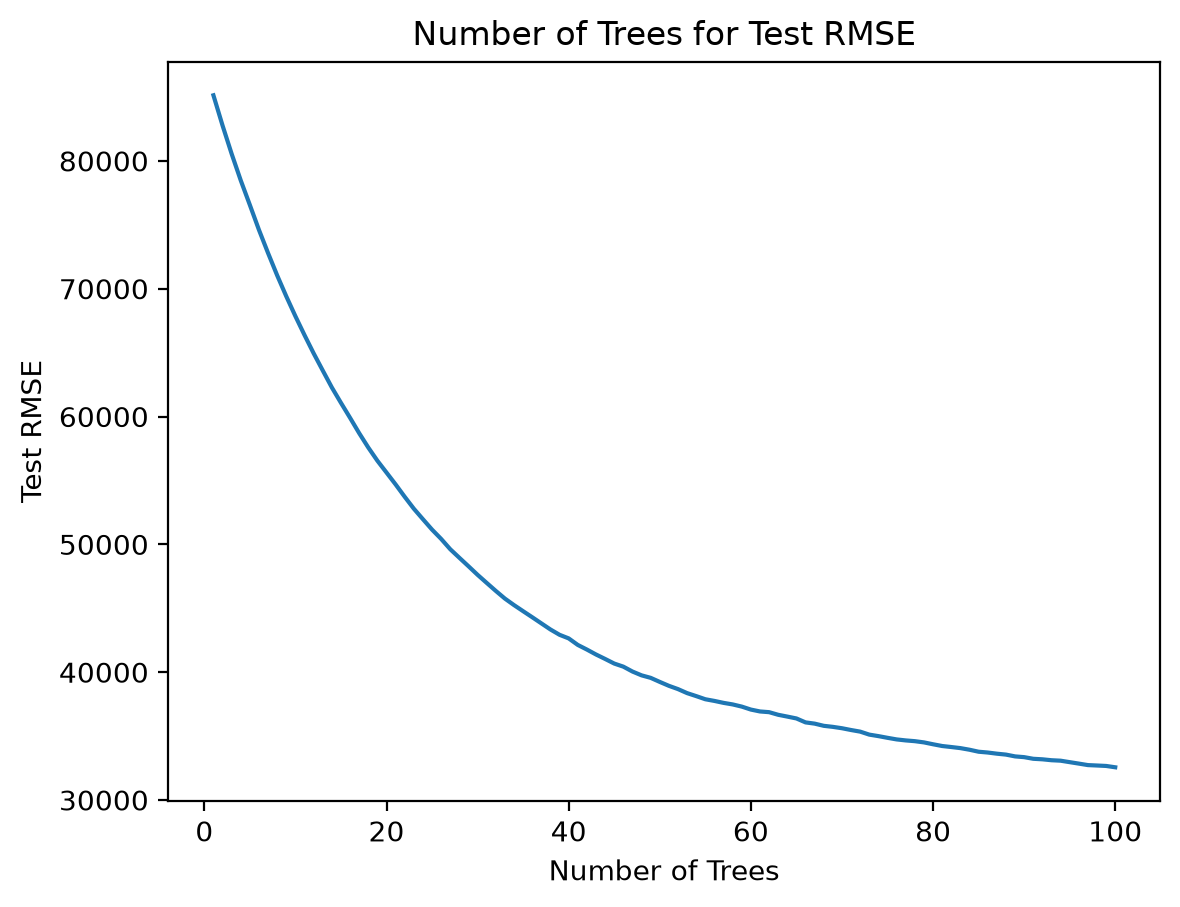

In [2]:
# TODO
# GradientBoostingRegressor를 학습하고
# staged_predict()를 이용해 단계별 Test RMSE를 확인하세요.

gbm_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=2, random_state=42)

gbm_model.fit(X_train, y_train)

gbm_rmse = []

for pred in gbm_model.staged_predict(X_test):
    rmse = root_mean_squared_error(y_test, pred)
    gbm_rmse.append(rmse)

plt.plot(range(1, 101), gbm_rmse)

plt.xlabel("Number of Trees")
plt.ylabel("Test RMSE")
plt.title("Number of Trees for Test RMSE")

plt.show()


- 하이퍼파라미터 의미:
    - `n_estimators=100`인 의미 : 최대 100개의 순차적으로 보정을 하는 나무를 추가한다.
    - `learnnig_rate=0.05`의 믜미 : 새 나무의 보정값을 0.05배 하여 현재 예측에 더하겠다.
    - `max_depth=2`의 의미: 개별 나무의 깊이를 최대 2개로 제한한다.

- Train에서 남은 오차를 다음 나무가 학습한다.
- 잔차(실제값-예측값)를 지속적으로 줄여나가는 모델

- RMSE : 

    - 예측오차를 제곱하여 평균을 낸 뒤 제곱근을 취한다. -> 작을 수록 좋은 값

    - 완벽한 예측은 0에 수렴한다.
    - 오차가 제곱이 되어 더 크게 반영되기 떄문에 더 큰 오차를 탐지해낼 수 있다.
    - 판매가격이 달러라면 RMSE도 달러로 해석 할 수 있다.
    - RMSE가 32,847이라는 것은 제곱평균제곱근으로 요약한 오차의 크기가 32,847달러라는 의미

- 나무가 많아질 수록 Test의 오차는 무조건 내려가는가?
    - 학습은 Train의 손실을 줄이는 방향으로 진행하기 때문에 Test의 정담으로 보정 나무를 학습하지는 않는다.
    - Train의 나무를 계속 추가하면 Train의 노이즈까지 학습하여 성능결과가 좋지 않을 수 있음.

- `staged_predict` / `Early Stopping`
    - `staged_predict` : 100단계까지 학습한 뒤 Test 예측을 관찰하는 것. 중간에 가장 좋은 학습단계가 있어도(손실이 적은) 100번을 채울 때까지 멈추지 않음
    - `Early Stopping` : n번만큼 학습했을 때 손실이 더 이상 줄어들지 않는 지점을 찾아서 모델을 종료


---

### Q2. 부스팅에서 나무를 순차적으로 추가하는 이유는 무엇인가요?

**답변:**  

- 앞선 모델이 남긴 오차를 다음 모델이 학습하여 아직 성명이 충분히 되지 않은 패턴을 계속 보완하려고 함 


---

# 필수 2. XGBoost와 LightGBM 비교

## 문제 1. 두 모델을 같은 조건에서 학습하세요.

### 요구사항

다음 공통 설정을 사용합니다.

- `n_estimators=200`
- `learning_rate=0.05`
- `max_depth=3`
- `random_state=42`

다음 두 모델을 학습합니다.

- `XGBRegressor`
- `LGBMRegressor`

각 모델에 대해 다음을 확인합니다.

1. 학습 시간
2. Test RMSE

### 확인 포인트

- XGBoost와 LightGBM을 같은 데이터와 같은 주요 하이퍼파라미터 조건에서 비교했는가?
- LightGBM이 빠른 학습을 강점으로 갖는다는 교안 내용과 연결할 수 있는가?

In [3]:
# TODO
# XGBoost와 LightGBM의 학습 시간과 Test RMSE를 비교하세요.

models ={
'XGB' : XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),
'LGBM' : LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, verbosity=-1, random_state=42)
}

result = []

for name, model in models.items():
    start=time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start

    pred = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, pred)

    result.append({
        'model' : name,
        'RMSE' : rmse,
        'train time(s)' : train_time
    })

result = pd.DataFrame(result).round(4)

result

,model,RMSE,train time(s)
0,XGB,28405.3203,0.1505
1,LGBM,31813.0916,0.1264


1. Depth-wise : 뿌리에 가까운 깊이의 노드를 우선 확장 (같은 깊이의 노드를 균등하게 확장하려고 함)
2. Leaf-wise : 현재 잎들 중 손실을 가장 많이 줄일 분할을 우선 확장 (손실 감소가 많았던 친구부터 확장하려고 함)
- XGBoost의 기본적인 Depth-wise 성장을 따르고 LightGBM은 Leaf-wise를 따른다.

- 현재 지표로만 대표적인 모델을 설정하는 것은 무리이므로 다른 성능평가지표도 함께 체크해야함
- 현재 지표로만 대표적인 모델을 설정해본다면 RMSE와 시간 효율성이 좋은 XGBoost를 선택한다.

---

### Q3. XGBoost와 LightGBM의 기본 트리 성장 방식 차이는 무엇인가요?

**답변:**  
- XGBoost의 기본적인 Depth-wise성장을 따르고 LightGBM은 Leaf-wise를 따른다.


### Q4. CatBoost의 구조적 특징과 강점은 무엇인가요?

**답변:**  
- Symmetric Tree 구조 사용, 같은 깊이의 노드에 같은 분할 조건을 적용
- 범주형 변수 처리에 유리

---

## 문제 2. learning_rate와 n_estimators의 관계를 확인하세요.

### 요구사항

다음 조합을 비교합니다.

```python
settings = [
    {"learning_rate": 0.1, "n_estimators": 50},
    {"learning_rate": 0.05, "n_estimators": 100},
    {"learning_rate": 0.01, "n_estimators": 300}
]
```

각 조합에 대해 `GradientBoostingRegressor(max_depth=2, random_state=42)`를 학습하고 다음을 확인합니다.

1. Test RMSE
2. 학습 시간

### 확인 포인트

- learning_rate가 작을수록 더 많은 나무가 필요할 수 있음을 확인했는가?
- 성능뿐 아니라 학습 시간도 함께 확인했는가?

In [4]:
# TODO
# learning_rate / n_estimators 조합별 Test RMSE와 학습 시간을 비교하세요.

settings = [
    {"learning_rate": 0.1, "n_estimators": 50},
    {"learning_rate": 0.05, "n_estimators": 100},
    {"learning_rate": 0.01, "n_estimators": 300}
]


results = []

for setting in settings:
    learning_rate = setting["learning_rate"]
    n_estimators = setting["n_estimators"]

    start = time.time()

    gbm = GradientBoostingRegressor(max_depth=2, 
                                    learning_rate=learning_rate, 
                                    n_estimators=n_estimators, 
                                    random_state=42
)

    gbm.fit(X_train, y_train)

    train_time = time.time() - start

    y_pred = gbm.predict(X_test)

    rmse = root_mean_squared_error(y_test, y_pred)

    results.append({
        'learning_rate' : learning_rate,
        'n_estimators' : n_estimators,
        'RMSE' : rmse,
        'train time' : train_time
    })

results = pd.DataFrame(results).round(4)

results



,learning_rate,n_estimators,RMSE,train time
0,0.10,50,31791.2832,0.0549
1,0.05,100,32559.1863,0.0949
2,0.01,300,37165.9913,0.2794


- `learning_rate=0.05` 의미 : 새 나무가 출력한 보정값을 0.05배하여 더한다는 뜻

- 작은 학습률에서 더 많은 나무가 필요한 경우가 있는지?
    - learning_rate가 작으면 유용한 패턴을 누적하여 학습하는 데에 오랜 시간과 단계가 필요할 수 있다.
    - 작은 학습률은 점진적인 학습을 가능하게 하지만
    - 주어진 나무의 수가 적다면 보정이 덜 된 상태로 학습이 끝날 가능성이 있다.

---

### Q5. learning_rate를 작게 만들면 왜 n_estimators를 함께 늘려야 할 수 있나요?

**답변:**  

- 각 나무가 최종 예측에 반영되는 비율이 작기 때문에 
- 같은 정도의 오차 보완을 위해 더 많은 단계가 필요할 수 있다.

---

# 과제 1. Early Stopping과 부스팅 모델 선택

## 배경

교안에서는 `n_estimators`를 충분히 크게 설정하고, 검증 성능이 더 이상 좋아지지 않으면 학습을 멈추는 **Early Stopping**을 소개했습니다.

이번 과제에서는 XGBoost에서 이 흐름을 적용합니다.

> 과제는 필수 실습에서 사용한 모델과 하이퍼파라미터를 그대로 활용하는 수준입니다.

## 요구사항

1. Train 데이터를 다시 Train / Validation으로 나눕니다.
2. `XGBRegressor`를 사용합니다.
3. `n_estimators=1000`
4. `learning_rate=0.05`
5. `max_depth=3`
6. `early_stopping_rounds=20`
7. Train 데이터로 학습하고 Validation 데이터를 `eval_set`으로 전달합니다.
8. Test 데이터의 RMSE를 계산합니다.
9. 실제로 사용된 나무 수를 확인합니다.
10. `n_estimators=1000`을 모두 사용하지 않고 중간에 멈췄다면 그 이유를 설명합니다.

11. Q7에서 배깅·랜덤포레스트·부스팅의 작동 원리와 편향·분산, 과적합에 미치는 영향을 비교합니다. 새로운 모델 학습 코드는 요구하지 않습니다.

### 확인 포인트

- Early Stopping이 Validation 성능을 기준으로 동작한다는 점을 이해했는가?
- 불필요하게 많은 나무를 쌓는 것을 막는 목적을 설명할 수 있는가?
- 과적합 방지와 학습 시간 절약이라는 두 가지 의미를 설명할 수 있는가?
- 배깅의 부트스트랩·예측 결합, 랜덤포레스트의 특성 무작위 선택, 부스팅의 순차적 오류 보완을 설명할 수 있는가?
- 각 방식이 편향·분산에 미치는 일반적인 영향과 과적합 가능성을 구분할 수 있는가?


In [5]:
# TODO
# XGBoost에 Early Stopping을 적용하세요.


# 1. Train / Validation 분할
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


# 2. XGBoost 모델 생성
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    early_stopping_rounds=20,
    eval_metric="rmse",
    random_state=42,
    n_jobs=1
)


# 3. 모델 학습
xgb_model.fit(X_tr,y_tr, eval_set=[(X_val, y_val)], verbose=False)


# 4. Test 데이터 예측
y_pred = xgb_model.predict(X_test)


# 5. Test RMSE 계산
test_rmse = root_mean_squared_error(y_test, y_pred)


# 6. 최적 나무 수 확인
best_iteration = xgb_model.best_iteration
best_n_estimators = best_iteration + 1

# 실제 학습된 나무 수
trained_trees = xgb_model.get_booster().num_boosted_rounds()

# 7. 결과 출력
print("Test RMSE:", test_rmse)
print("최적 반복 횟수:", best_n_estimators)
print("실제 학습된 나무 수:", trained_trees)


# 8. Early Stopping 확인
if trained_trees < 1000:
    print("Early Stopping으로 학습이 조기 종료되었습니다.")
else:
    print("설정한 최대 1000번까지 학습했습니다.")

Test RMSE: 30332.87890625
최적 반복 횟수: 108
실제 학습된 나무 수: 128
Early Stopping으로 학습이 조기 종료되었습니다.


- `Early Stopping`을 사용하는 이유
    
    - 학습을 멈출 수 있는 장치인 `Early Stopping`이 없다면 최적의 RMSE를 보여도 모델은 멈추지 않고 학습할 수 있다.
    
    - `Early Stopping`은 가장 좋은 단계의 나무 수를 통해 손실에 갱신이 없으면 학습을 강제로 종료하여 최적의 성능과 시간적 효율을 높이기 위함

---

### Q6. Early Stopping은 어떤 상황에서 학습을 멈추나요?

**답변:**  

- Early Stopping은 학습 과정에서 Validation의 성능이 일정 횟수 동안 개선되지 않으면 학습을 중단한다.

- `early_stopping_rounds=20` 으로 Validation RMSE가 20번 연속으로 개선되지 않으면 학습을 중단한다.


### Q7. 배깅·랜덤포레스트·부스팅의 작동 원리와 편향·분산에 미치는 영향을 비교하세요.

다음 항목을 포함하여 각 방법을 설명하세요.

1. **배깅:** 부트스트랩 표본을 만드는 방법과 여러 모델의 예측을 결합하는 방법, 분산 감소의 이유
2. **랜덤포레스트:** 배깅에 더해 각 노드의 분할 후보 특성을 무작위로 선택하는 이유와 트리 간 상관·분산에 미치는 영향
3. **부스팅:** 이전 모델의 오류를 순차적으로 보완하는 원리와 편향 감소의 관계, 과적합 가능성 및 이를 줄이는 방법

> 편향·분산에 대한 효과는 일반적인 경향입니다. 한 방법이 편향 또는 분산만 바꾸거나 과적합을 항상 막는다고 단정하지 마세요.

**답변:**

- 배깅

    - 원본 데이터에서 중복을 허용하는 복원추출 방식으로 표본을 추출한다.

    - 추출한 표본에서 만들어진 부트스트랩으로 모델의 예측을 결합하며, 예측 결과의 회귀는 평균, 분류모델은 다수결로 최종 예측을 한다.

    - 여러 모델을 사용하기 때문에 개별 모델의 예측 변동성은 줄어들고, 분산을 감소시킨다. 

- 랜덤포레스트

    - 배깅을 기반으로 여러 트리를 학습하는 앙상블 모델이다.

    - 각 노드에서 분할 할 때 전체 특성이 아닌 무작위로 선택한 일부 특성만을 분할 후보로 사용한다.

    - 배깅과 같이 여러 트리를 학습하여 예측 결과를 내기 떄문에 분산을 감소시킨다.

    - 무작위로 표본을 추출하기 떄문에 편향이 증가할 수 있다.

- 부스팅

    - 여러 모델을 순차적으로 학습하면서 그 전 모델의 오차를 점진적으로 줄여가면서 학습하는 방식이다.

    - 이전 모델이 학습하지 못했던 오차를 다음 모델이 줄여나가면서 학습을 진행하기 떄문에 편향을 감소시킨다.

    - 하지만 나무 수가 지나치게 많아지면 모델이 복잡해지게 되기 때문에 학습 데이터에만 일반화 가능성을 생기게 하여 과적합이 될 가능성이 있다.
    - 따라서 `n_estimators`, `learning_rate`, `max_depth`, `early_stopping_rounds` 등의 하이퍼파라미터를 조절하여 과적합을 완화해야한다.


---

# 실습 마무리

아래 질문에 짧게 답해보세요.

1. 부스팅은 여러 모델을 병렬로 학습하나요, 순차적으로 학습하나요?
    - 순차학습

2. AdaBoost는 이전 모델이 틀린 샘플을 어떻게 처리하나요?
    - 이전 모델이 틀린 샘플의 가중치를 높인다.

3. Gradient Boosting은 다음 모델이 무엇을 학습하나요?
    - 이전 모델이 남긴 잔차를 다음 모델이 학습한다.

4. XGBoost와 LightGBM의 기본 트리 성장 방식은 어떻게 다른가요?
    - XGBoost : Level-wise
    - LightGBM : Leaf-wise

5. `learning_rate`와 `n_estimators`는 어떤 관계가 있나요?
    - `learning_rate`가 작을수록 일반적으로 더 많은 나무 `n_estimators`가 필요할 수 있다.

6. Early Stopping을 사용하는 이유는 무엇인가요?
    - Validation 성능이 더 이상 좋아지지 않을 때(학습 손실이 더 이상 줄어들지 않을 때)
    - 학습을 멈춰서 과적합이 불필요한 학습을 줄인다.

7. 부스팅은 편향과 분산 중 어떤 문제를 줄이는 데 특히 초점을 두나요?
    - 단계적으로 이전 오차를 보완하면서 편향을 줄이는 데 초점을 둔다.